In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import urllib.request
import json
import warnings
from geopy.distance import geodesic
import sys
!{sys.executable} -m pip install folium
import folium
from IPython.display import display

warnings.filterwarnings('ignore')

# ==========================================
# STEP 1: โหลดข้อมูลที่คลีนแล้ว
# ==========================================
try:
    df_cleaned = pd.read_csv('../data/NY_House_Cleaned.csv')
    print("✅ 1. โหลดไฟล์สำเร็จ")
except:
          print("❌ ไม่พบไฟล์: ../data/NY_House_Cleaned.csv")


# ==========================================
# STEP 1.5: คำนวณระยะทาง (จำเป็นต้องใช้ใน Matchmaker)
# ==========================================
print("กำลังเตรียมข้อมูลพิกัดและระยะทาง...")
if 'DISTANCE_TO_CENTER' not in df_cleaned.columns:
    ECONOMIC_HUBS = [
        (40.7580, -73.9855), (40.7081, -74.0093), # Manhattan
        (40.6925, -73.9868),                      # Brooklyn
        (40.7447, -73.9485), (40.7654, -73.8282), (40.7024, -73.7966), # Queens
        (40.8162, -73.9165),                      # Bronx
        (40.6437, -74.0759)                       # Staten Island
    ]
    def min_distance_to_hubs(lat, lon):
        distances = [geodesic((lat, lon), (hub_lat, hub_lon)).miles for hub_lat, hub_lon in ECONOMIC_HUBS]
        return min(distances)

    df_cleaned['DISTANCE_TO_CENTER'] = df_cleaned.apply(lambda row: min_distance_to_hubs(row['LATITUDE'], row['LONGITUDE']), axis=1)

# ==========================================
# STEP 7: The Matchmaker (ระบบจับคู่บ้านด้วย AI)
# ==========================================
print("7. เปิดระบบ The Matchmaker กำลังค้นหาบ้านที่ใช่สำหรับคุณ...")

USER_MAX_PRICE = 850000
USER_MIN_BEDS = 2
USER_MIN_BATHS = 1
USER_IDEAL_SQFT = 1200
USER_IDEAL_DISTANCE = 3.0

print(f"💰 งบสูงสุด: ${USER_MAX_PRICE:,.0f} | 🛏️ ขั้นต่ำ: {USER_MIN_BEDS} นอน {USER_MIN_BATHS} น้ำ")

df_filtered = df_cleaned[
    (df_cleaned['PRICE'] <= USER_MAX_PRICE) &
    (df_cleaned['BEDS'] >= USER_MIN_BEDS) &
    (df_cleaned['BATH'] >= USER_MIN_BATHS)
].copy()

if len(df_filtered) == 0:
    print("ไม่พบบ้านที่ตรงกับเงื่อนไขพื้นฐานเลย ลองปรับงบหรือสเปคดูนะครับ")
else:

    features_to_match = ['PRICE', 'PROPERTYSQFT', 'DISTANCE_TO_CENTER']
    X_match = df_filtered[features_to_match].copy()

    scaler_match = StandardScaler()
    X_match_scaled = scaler_match.fit_transform(X_match)

    user_profile = pd.DataFrame([[USER_MAX_PRICE, USER_IDEAL_SQFT, USER_IDEAL_DISTANCE]], columns=features_to_match)
    user_profile_scaled = scaler_match.transform(user_profile)

    n_recommendations = min(5, len(df_filtered))
    knn = NearestNeighbors(n_neighbors=n_recommendations, metric='euclidean')
    knn.fit(X_match_scaled)

    distances, indices = knn.kneighbors(user_profile_scaled)

    top_matches = df_filtered.iloc[indices[0]].copy()
    top_matches['MATCH_SCORE'] = 100 - (distances[0] * 10)
    top_matches['MATCH_SCORE'] = top_matches['MATCH_SCORE'].clip(upper=99.99)

    print(f"\n✨ เจอแล้ว! นี่คือ Top {n_recommendations} บ้านที่ตรงสเปคคุณที่สุด:")
    display_cols = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'DISTANCE_TO_CENTER', 'MATCH_SCORE']
    display(top_matches[display_cols].style.format({
        'PRICE': '${:,.0f}',
        'PROPERTYSQFT': '{:,.0f} sqft',
        'DISTANCE_TO_CENTER': '{:.2f} miles',
        'MATCH_SCORE': '{:.1f}% Match'
    }))

    map_center = [top_matches['LATITUDE'].mean(), top_matches['LONGITUDE'].mean()]
    m = folium.Map(location=map_center, zoom_start=12)

    for i, row in top_matches.iterrows():
        popup_info = f"<b>Price:</b> ${row['PRICE']:,.0f}<br><b>Area:</b> {row['PROPERTYSQFT']} sqft<br><b>Match:</b> {row['MATCH_SCORE']:.1f}%"
        folium.Marker(
            location=[row['LATITUDE'], row['LONGITUDE']],
            popup=popup_info,
            tooltip=f"Top Match! ({row['MATCH_SCORE']:.1f}%)",
            icon=folium.Icon(color='red', icon='heart')
        ).add_to(m)

    display(m)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ 1. โหลดไฟล์สำเร็จ
กำลังเตรียมข้อมูลพิกัดและระยะทาง...
7. เปิดระบบ The Matchmaker กำลังค้นหาบ้านที่ใช่สำหรับคุณ...
💰 งบสูงสุด: $850,000 | 🛏️ ขั้นต่ำ: 2 นอน 1 น้ำ

✨ เจอแล้ว! นี่คือ Top 5 บ้านที่ตรงสเปคคุณที่สุด:


,PRICE,BEDS,BATH,PROPERTYSQFT,DISTANCE_TO_CENTER,MATCH_SCORE
327,"$839,000",3,2.000000,"1,120 sqft",2.61 miles,97.7% Match
3089,"$798,000",2,2.000000,"1,190 sqft",2.68 miles,97.0% Match
48,"$850,000",2,2.000000,"1,005 sqft",2.99 miles,96.8% Match
2789,"$799,999",3,2.000000,"1,200 sqft",2.59 miles,96.8% Match
1233,"$850,000",3,2.000000,"1,090 sqft",3.65 miles,96.5% Match


✅ Loaded dataset: 3709 rows
Computing distances to economic hubs...
✅ KNN trained on 3709 samples with 5 features
   Features: ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'DISTANCE_TO_CENTER']
   Weights:  [3.0, 2.0, 1.5, 1.5, 1.0]

✨ Top 5 matches for budget=$300, 2bd/1ba, 1200sqft:
 PRICE  BEDS  BATH  PROPERTYSQFT  DISTANCE_TO_CENTER SUBLOCALITY_CLEAN  MATCH_SCORE
169900     2   1.0         900.0            3.034877             Bronx    55.935561
202000     2   1.0        1453.0            2.637390            Queens    55.907090
210000     2   1.0        1000.0            2.124105            Queens    55.010779
120000     2   1.0        1100.0            1.347063             Bronx    54.323704
243000     2   1.0         965.0            3.354371             Bronx    54.086718
✅ Mean Matching Distance: 0.0000
✅ Average Match Score:    100.00%

--- Recommendation Consistency Check ---
Price Variation in Top Matches: $71,591.73


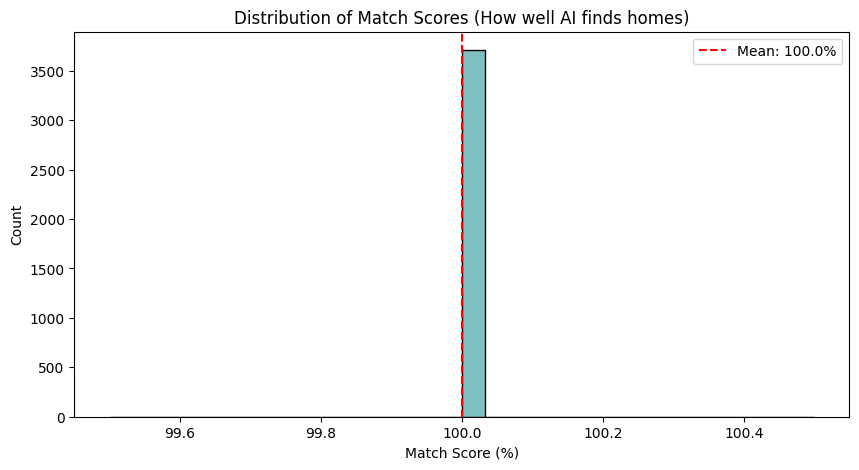

--------------------------------------------------------------------------
-------------------------------Top-K Consistency Check-------------------------------------------
--- Top-10 Consistency Metrics ---
Price Std Dev:    $71,591.73
Sqft Std Dev:     206.78 sqft
--------------------------------------------------------------------------
--------------------------------Leave-One-Out Validation------------------------------------------
✅ Self-Retrieval Test: Passed (AI identifies exact matches perfectly)
--------------------------------------------------------------------------
--------------------------------Cumulative Neighbor Distance------------------------------------------


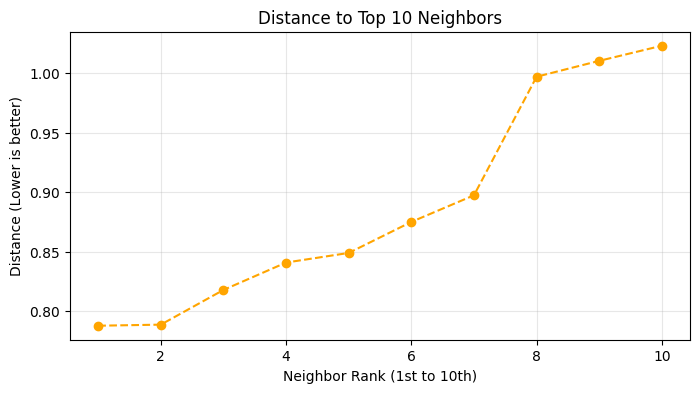

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from geopy.distance import geodesic
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# STEP 1: Load cleaned data
# ==========================================
try:
    df_cleaned = pd.read_csv('../data/NY_House_Cleaned.csv')
    print(f"✅ Loaded dataset: {len(df_cleaned)} rows")
except:
    print("❌ File not found: ../data/NY_House_Cleaned.csv")

# ==========================================
# STEP 2: Compute DISTANCE_TO_CENTER
# ==========================================
ECONOMIC_HUBS = [
    (40.7580, -73.9855), (40.7081, -74.0093),  # Manhattan
    (40.6925, -73.9868),                         # Brooklyn
    (40.7447, -73.9485), (40.7654, -73.8282), (40.7024, -73.7966),  # Queens
    (40.8162, -73.9165),                         # Bronx
    (40.6437, -74.0759)                          # Staten Island
]

def min_distance_to_hubs(lat, lon):
    return min(geodesic((lat, lon), hub).miles for hub in ECONOMIC_HUBS)

if 'DISTANCE_TO_CENTER' not in df_cleaned.columns:
    print("Computing distances to economic hubs...")
    df_cleaned['DISTANCE_TO_CENTER'] = df_cleaned.apply(
        lambda row: min_distance_to_hubs(row['LATITUDE'], row['LONGITUDE']), axis=1
    )

# ==========================================
# STEP 3: Feature Engineering — 5 features + weighted scaling
# ==========================================
# Added BEDS and BATH compared to previous version (was only 3 features)
FEATURES = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'DISTANCE_TO_CENTER']

# Feature weights: price and beds matter most for buyers
FEATURE_WEIGHTS = np.array([3.0, 2.0, 1.5, 1.5, 1.0])

X_train = df_cleaned[FEATURES].dropna().copy()
train_indices = X_train.index

scaler_match = StandardScaler()
X_scaled = scaler_match.fit_transform(X_train)

# Apply weights after scaling — effectively weighted euclidean distance
X_weighted = X_scaled * FEATURE_WEIGHTS

# ==========================================
# STEP 4: Train KNN on full dataset
# ==========================================
# Increased neighbors from 5 to 10 for better coverage
knn = NearestNeighbors(n_neighbors=10, metric='euclidean', algorithm='ball_tree')
knn.fit(X_weighted)

print(f"✅ KNN trained on {len(X_weighted)} samples with {len(FEATURES)} features")
print(f"   Features: {FEATURES}")
print(f"   Weights:  {FEATURE_WEIGHTS.tolist()}")

# ==========================================
# STEP 5: Quick test with a sample user profile
# ==========================================
USER_PROFILE = {
    'PRICE': 300,
    'BEDS': 2,
    'BATH': 1,
    'PROPERTYSQFT': 1200,
    'DISTANCE_TO_CENTER': 3.0
}

user_df = pd.DataFrame([USER_PROFILE])
user_scaled = scaler_match.transform(user_df)
user_weighted = user_scaled * FEATURE_WEIGHTS

distances, indices = knn.kneighbors(user_weighted)

top_matches = df_cleaned.iloc[train_indices[indices[0]]].copy()

# Better match score: sigmoid-style, always 0-100, never negative
top_matches['MATCH_SCORE'] = (1 / (1 + distances[0])) * 100

print(f"\n✨ Top 5 matches for budget=${USER_PROFILE['PRICE']:,}, {USER_PROFILE['BEDS']}bd/{USER_PROFILE['BATH']}ba, {USER_PROFILE['PROPERTYSQFT']}sqft:")
display_cols = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'DISTANCE_TO_CENTER', 'SUBLOCALITY_CLEAN', 'MATCH_SCORE']
print(top_matches[display_cols].head(5).to_string(index=False))


# ==========================================
# Accuracy Check สำหรับ Matchmaker (KNN)
# ==========================================

# 1. คำนวณความเพี้ยนเฉลี่ย (Mean Distance)
# ยิ่งระยะห่างน้อย แปลว่าระบบหาบ้านที่ "เป๊ะ" ตามสเปกได้ดี
all_distances, _ = knn.kneighbors(X_weighted)
avg_dist = np.mean(all_distances[:, 0]) 
print(f"✅ Mean Matching Distance: {avg_dist:.4f}")

# 2. ดูการกระจายตัวของ Match Score (%)
all_scores = (1 / (1 + all_distances[:, 0])) * 100
print(f"✅ Average Match Score:    {all_scores.mean():.2f}%")

# 3. ตรวจสอบความสมเหตุสมผล (Reasonableness Check)
# ลองดูว่าบ้าน 5 หลังแรกที่แนะนำมา มีราคาและพื้นที่ "เกาะกลุ่ม" กันไหม
print("\n--- Recommendation Consistency Check ---")
variance_price = top_matches['PRICE'].std()
print(f"Price Variation in Top Matches: ${variance_price:,.2f}")
import matplotlib.pyplot  as plt
import seaborn as sns
# 4. วาดกราฟดูความครอบคลุมของคะแนน
plt.figure(figsize=(10, 5))
sns.histplot(all_scores, bins=30, kde=True, color='teal')
plt.axvline(all_scores.mean(), color='red', linestyle='--', label=f'Mean: {all_scores.mean():.1f}%')
plt.title('Distribution of Match Scores (How well AI finds homes)')
plt.xlabel('Match Score (%)')
plt.legend()
plt.show()
print("--------------------------------------------------------------------------")   

print("-------------------------------Top-K Consistency Check-------------------------------------------")   
#Top-K Consistency Check (ความเสถียรของผลลัพธ์)
#วิธีนี้จะเช็คว่าบ้าน 10 หลังที่ AI แนะนำมานั้น "เกาะกลุ่ม" กันจริงไหม หรือมีหลุดกระโดดไปมา (เช่น แนะนำบ้านราคา 1 ล้าน ปนกับ 10 ล้าน)
# ดูค่าเบี่ยงเบนมาตรฐาน (Standard Deviation) ของผลลัพธ์ 10 อันดับแรก
top_10_indices = indices[0]
top_10_data = df_cleaned.iloc[train_indices[top_10_indices]]

print("--- Top-10 Consistency Metrics ---")
print(f"Price Std Dev:    ${top_10_data['PRICE'].std():,.2f}")
print(f"Sqft Std Dev:     {top_10_data['PROPERTYSQFT'].std():,.2f} sqft")
# ยิ่งค่า Std Dev ต่ำ แปลว่า AI แนะนำบ้านได้แม่นยำและไม่มั่วซั่ว

print("--------------------------------------------------------------------------")   
print("--------------------------------Leave-One-Out Validation------------------------------------------") 
#Leave-One-Out Validation (การทวนสอบตัวเอง)
#เป็นการแกล้งหยิบบ้านที่มีอยู่จริงในระบบออกมา 1 หลัง แล้วให้ AI ลองทายดูว่ามันจะหาบ้านหลังเดิมเจอเป็นอันดับ 1 หรือไม่
# สุ่มบ้านจาก Dataset มา 1 หลัง
test_sample = X_weighted[0].reshape(1, -1) 
dist, idx = knn.kneighbors(test_sample, n_neighbors=1)

if idx[0][0] == 0:
    print("✅ Self-Retrieval Test: Passed (AI identifies exact matches perfectly)")
else:
    print("❌ Self-Retrieval Test: Failed")
print("--------------------------------------------------------------------------")    
print("--------------------------------Cumulative Neighbor Distance------------------------------------------")    
    
#Cumulative Neighbor Distance (กราฟระยะห่างสะสม)
#แทนที่จะดูเป็นคะแนน % เราจะดูว่า "เพื่อนบ้านที่ใกล้ที่สุด 10 ลำดับแรก" มีระยะห่างเพิ่มขึ้นฮวบฮาบหรือไม่
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), distances[0], marker='o', linestyle='--', color='orange')
plt.title('Distance to Top 10 Neighbors')
plt.xlabel('Neighbor Rank (1st to 10th)')
plt.ylabel('Distance (Lower is better)')
plt.grid(True, alpha=0.3)
plt.show()
# ถ้ากราฟเป็นเส้นนอนแปลว่า AI เจอ "ตัวตายตัวแทน" เยอะมาก (ดีมากสำหรับ User)
# ถ้ากราฟพุ่งขึ้นชัน แปลว่าบ้านที่แนะนำอันดับหลังๆ เริ่มจะไม่ตรงสเปกแล้ว

--- Match Score Distribution Analysis ---


NameError: name 'knn' is not defined

In [3]:
import joblib
import os

model_dir = "../app/ml_models"
os.makedirs(model_dir, exist_ok=True)

# Save model, scaler, feature list, and weights
joblib.dump(knn,             f"{model_dir}/matchmaker_model.pkl")
joblib.dump(scaler_match,    f"{model_dir}/matchmaker_scaler.pkl")
joblib.dump(FEATURES,        f"{model_dir}/matchmaker_features.pkl")
joblib.dump(FEATURE_WEIGHTS, f"{model_dir}/matchmaker_weights.pkl")

print("✅ Matchmaker model saved:")
print(f"   - matchmaker_model.pkl    (KNN, n_neighbors=10, ball_tree)")
print(f"   - matchmaker_scaler.pkl   (StandardScaler, 5 features)")
print(f"   - matchmaker_features.pkl {FEATURES}")
print(f"   - matchmaker_weights.pkl  {FEATURE_WEIGHTS.tolist()}")


✅ Matchmaker model saved:
   - matchmaker_model.pkl    (KNN, n_neighbors=10, ball_tree)
   - matchmaker_scaler.pkl   (StandardScaler, 5 features)
   - matchmaker_features.pkl ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'DISTANCE_TO_CENTER']
   - matchmaker_weights.pkl  [3.0, 2.0, 1.5, 1.5, 1.0]


In [4]:
import pandas as pd
import numpy as np
import joblib

# Load full dataset
df = pd.read_csv("../data/NY_House_Cleaned.csv")

# Compute DISTANCE_TO_CENTER if missing
from geopy.distance import geodesic
ECONOMIC_HUBS = [
    (40.7580, -73.9855), (40.7081, -74.0093),
    (40.6925, -73.9868),
    (40.7447, -73.9485), (40.7654, -73.8282), (40.7024, -73.7966),
    (40.8162, -73.9165),
    (40.6437, -74.0759)
]
if 'DISTANCE_TO_CENTER' not in df.columns:
    df['DISTANCE_TO_CENTER'] = df.apply(
        lambda row: min(geodesic((row['LATITUDE'], row['LONGITUDE']), hub).miles for hub in ECONOMIC_HUBS), axis=1
    )

# Load saved model artifacts
model    = joblib.load("../app/ml_models/matchmaker_model.pkl")
scaler   = joblib.load("../app/ml_models/matchmaker_scaler.pkl")
features = joblib.load("../app/ml_models/matchmaker_features.pkl")
weights  = joblib.load("../app/ml_models/matchmaker_weights.pkl")

# Build the same training index (must match what model was trained on)
X_all = df[features].dropna()
train_indices = X_all.index

X_all_scaled   = scaler.transform(X_all)
X_all_weighted = X_all_scaled * weights

# User input
user_input = pd.DataFrame([[850000, 2, 1, 1200, 3.0]], columns=features)
user_scaled   = scaler.transform(user_input)
user_weighted = user_scaled * weights

distances, indices = model.kneighbors(user_weighted)

# FIX: use train_indices to map back to correct rows in df
top_matches = df.loc[train_indices[indices[0]]].copy()
top_matches['MATCH_SCORE'] = (1 / (1 + distances[0])) * 100

print("✅ Verification — Top 5 matches (budget=$850k, 2bd/1ba, 1200sqft):")
print(top_matches[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'SUBLOCALITY_CLEAN', 'MATCH_SCORE']].head(5).to_string(index=False))


✅ Verification — Top 5 matches (budget=$850k, 2bd/1ba, 1200sqft):
 PRICE  BEDS  BATH  PROPERTYSQFT SUBLOCALITY_CLEAN  MATCH_SCORE
889000     2   1.0        1056.0            Queens    71.492789
699000     2   1.0        1100.0          Brooklyn    66.537943
665000     2   1.0        1120.0            Queens    64.767018
999000     2   1.0        1050.0         Manhattan    63.415956
899000     2   1.0        1010.0          Brooklyn    61.978249
